## Analysis

In [1]:
spark.version

'3.5.1'

In [2]:
import warnings
import pandas as pd
import numpy as np
from itertools import compress 
from pyspark.sql.functions import *
from pyspark.sql.types import *
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 10)
pd.reset_option('display.max_rows', 10)
pd.set_option('display.max_colwidth', 500)

warnings.filterwarnings(action='ignore')

In [3]:
import re
from pyspark.ml.feature import MinHashLSH
from pyspark.ml.feature import CountVectorizer,  IDF, CountVectorizerModel, Tokenizer, RegexTokenizer, StopWordsRemover
from pyspark.ml.feature import StopWordsRemover 
from pyspark import SparkContext
from pyspark.sql import SQLContext
from pyspark.sql import Row
import pyspark.sql.functions as F

In [4]:
spark.conf.set("spark.sql.repl.eagerEval.enabled",True)
spark.conf.set("spark.sql.repl.eagerEval.maxCharsPerCell", 200)

In [5]:
reviews_path = "gs://msca-bdp-students-bucket/notebooks/sharonlee/Final Project/review_data"
meta_path = "gs://msca-bdp-students-bucket/notebooks/sharonlee/Final Project/meta_data"

In [6]:
reviews = spark.read.parquet(reviews_path)
meta = spark.read.parquet(meta_path)

In [7]:
reviews.printSchema()

root
 |-- asin: string (nullable = true)
 |-- helpful_vote: long (nullable = true)
 |-- parent_asin: string (nullable = true)
 |-- rating: double (nullable = true)
 |-- text: string (nullable = true)
 |-- title: string (nullable = true)
 |-- user_id: string (nullable = true)
 |-- verified_purchase: boolean (nullable = true)
 |-- timestamp_df: timestamp (nullable = true)


In [8]:
meta.printSchema()

root
 |-- parent_asin: string (nullable = true)
 |-- title: string (nullable = true)
 |-- main_category: string (nullable = true)
 |-- price: string (nullable = true)
 |-- average_rating: double (nullable = true)
 |-- rating_number: long (nullable = true)
 |-- price_num: double (nullable = true)


In [7]:
# drop unnecessary columns
reviews_cols = [
    "parent_asin",
    "text",
    "title",
    "timestamp_df",
    "rating",             
    "verified_purchase"  
]
reviews = reviews.select(reviews_cols)

meta_cols = [
    "parent_asin",
    "main_category",
    "rating_number",      
    "average_rating"      
]

meta = meta.select(meta_cols)

### Pick Automotive category

In [8]:
# pick Automotives category
auto_products = meta.filter(F.col("main_category") == "Automotive") \
                    .select("parent_asin")
auto_reviews = reviews.join(auto_products, on="parent_asin", how="inner")

In [9]:
# duplicate titles?
title_dups = auto_reviews.groupBy("title").count() \
                         .filter(F.col("count") > 1)

n_titles = auto_reviews.select("title").count()
n_title_dups = title_dups.select(F.sum("count")).first()[0]

dup_title_rate = n_title_dups / n_titles

display(title_dups.orderBy("count", ascending=False).limit(10))
print("Percentage of the excact duplicate titles:", dup_title_rate)

title,count
Five Stars,1592629
Four Stars,248048
Great product,133829
One Star,113988
Great,97536
Three Stars,93034
Perfect,91441
Good,85819
Perfect fit,82609
Good product,74072


Percentage of the excact duplicate titles: 0.6077315992880062


In [9]:
# duplicate texts?
text_dups = auto_reviews.groupBy("text").count() \
                        .filter(F.col("count") > 1)

n_texts = auto_reviews.select("text").count()
n_text_dups = text_dups.select(F.sum("count")).first()[0]

dup_text_rate = n_text_dups / n_texts

display(text_dups.orderBy("count", ascending=False).limit(10))
print("Percentage of the excact duplicate review texts:", dup_text_rate)

text,count
Good,53254
Great,39557
Great product,38898
Works great,36991
Perfect,28270
Perfect fit,26321
Good product,24026
good,23763
Easy to install,21279
Excellent,17729


Percentage of the excact duplicate review texts: 0.18296786245027033


To assess whether Automotive reviews on Amazon are mostly unique or frequently reused, we measured exact duplication rates for both review titles and review texts. The results indicate substantial redundancy.  
About 60.8% of all review titles are exact repeats. The most common titles include extremely short sentiment labels such as "Five Stars," "Four Stars," "Great product," and "One Star." This shows that titles in this category tend to be really simple, generic, and highly repetitive, suggesting consistent templated behavior rather than unique user-generated phrasing.  
In addition, approximately 18.3% of all review texts appear more than once. Common repeated texts included one- or two-word statements such as "Good," "Great," "Works great," "Perfect," and "Easy to install." The heavy repetition of these short reviews indicates that many users just rely on minimal, formulaic phrasing.  

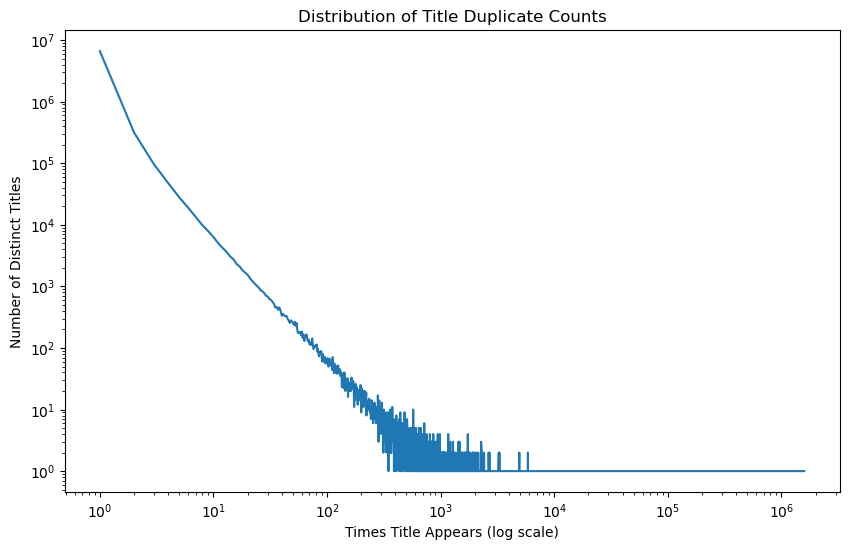

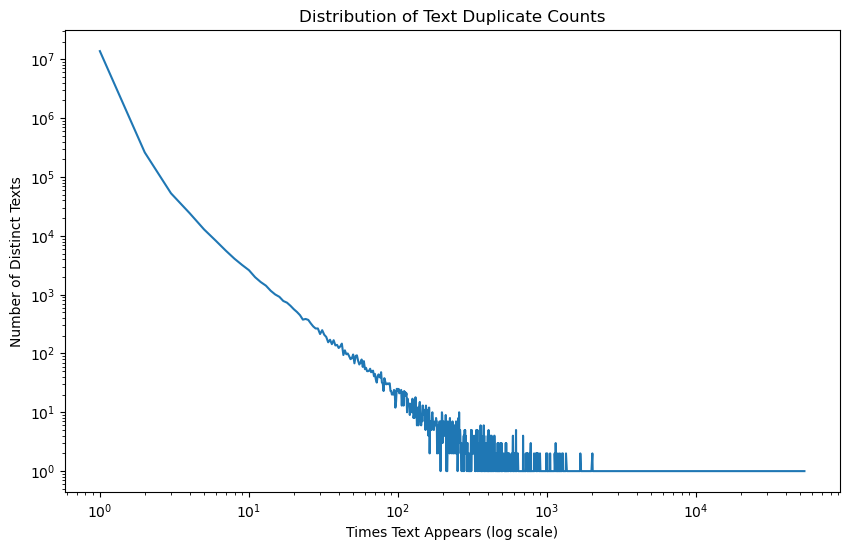

In [13]:
# distribution of duplicate frequency
# title
title_dist = (
    auto_reviews.groupBy("title")
    .count()
    .groupBy("count")
    .agg(F.count("*").alias("n_titles"))
    .orderBy("count")
)

title_dist_pd = title_dist.toPandas()

# text
text_dist = (
    auto_reviews.groupBy("text")
    .count()
    .groupBy("count")
    .agg(F.count("*").alias("n_texts"))
    .orderBy("count")
)

text_dist_pd = text_dist.toPandas()

plt.figure(figsize=(10,6))
plt.plot(title_dist_pd["count"], title_dist_pd["n_titles"])
plt.xscale("log")
plt.yscale("log")
plt.title("Distribution of Title Duplicate Counts")
plt.xlabel("Times Title Appears (log scale)")
plt.ylabel("Number of Distinct Titles")
plt.show()

plt.figure(figsize=(10,6))
plt.plot(text_dist_pd["count"], text_dist_pd["n_texts"])
plt.xscale("log")
plt.yscale("log")
plt.title("Distribution of Text Duplicate Counts")
plt.xlabel("Times Text Appears (log scale)")
plt.ylabel("Number of Distinct Texts")
plt.show()

In [10]:
auto_reviews = auto_reviews.filter(F.col("text").isNotNull() & (F.length(F.trim(F.col("text"))) > 0))
auto_reviews.show(5)

+-----------+--------------------+--------------------+--------------------+------+-----------------+
|parent_asin|                text|               title|        timestamp_df|rating|verified_purchase|
+-----------+--------------------+--------------------+--------------------+------+-----------------+
| B08L4JT1HC|Love this! I do m...|   Perfect lighting!|2021-04-29 02:55:...|   5.0|             true|
| B00FSAUC5K|using this you wi...|       Saved product| 2014-05-07 18:51:36|   4.0|             true|
| B00YAZBWZI|         great stuff|          Four Stars|2017-10-04 04:11:...|   4.0|             true|
| B01MYPD4JT|             perfect|          Five Stars|2018-07-06 12:54:...|   5.0|             true|
| B00NWGZ3A6|More Chinese land...|Lasted about a month| 2017-02-19 18:07:38|   1.0|             true|
+-----------+--------------------+--------------------+--------------------+------+-----------------+
only showing top 5 rows


In [9]:
# sample for faster computation
auto_sample = auto_reviews.sample(withReplacement=False, fraction=0.01, seed=42)

In [10]:
auto_text = auto_sample.select("parent_asin", "text", "timestamp_df")
auto_title = auto_sample.select("parent_asin", "title", "timestamp_df")

### 1. Clean data & remove stopwords

In [11]:
#### for text ####

# add 'id'
auto_text = auto_text.withColumn("id", monotonically_increasing_id())

# note: text is not lowercased, so "Great" and "great" count as different words
# remove punctuation and split into words
auto_text = auto_text.withColumn("clean_text", F.regexp_replace(F.col("text"), "[^a-zA-Z0-9\\s]", ""))
auto_text = auto_text.withColumn("text_words", split(F.col("clean_text"), " "))

# filter out tokens < 3 characters (remove 'is', 'a', 'am', etc)
auto_text = auto_text.withColumn("clean_words", F.expr("filter(text_words, word -> length(word) >= 3)"))

# remove stopwords
remover_text = StopWordsRemover(inputCol="clean_words", outputCol="filtered_words")
auto_text = remover_text.transform(auto_text)

auto_text = auto_text.select("id", "parent_asin", "timestamp_df", "text", "filtered_words")
auto_text = auto_text.filter(F.size(F.col("filtered_words")) >= 3) # exclude simple reviews - it won't help
display(auto_text.limit(5).toPandas())

,id,parent_asin,timestamp_df,text,filtered_words
0,0,B01IW1UJKE,2017-07-11 12:32:39.121,I was looking for something to hold my mirror and picture boxes together for moving. These worked fantastic. All arrived at the destination and were A-one compared to what the movers wanted to provide. I would recommend these for anyone needing to lash packaging together.,"[looking, something, hold, mirror, picture, boxes, together, moving, worked, fantastic, arrived, destination, Aone, compared, movers, wanted, provide, recommend, anyone, needing, lash, packaging, together]"
1,1,B00HRY5JX0,2017-09-04 19:34:00.921,"I bought these and had them installed, on 2009 Jeep Compass, the vehicle felt more comfortable on the road in terms of road handling for about 2 months, and it was back to the feeling of have no control on the roads. its like the vehicle was bouncing all over the road. just like before I replaced the old ones, they didn't last 3 months, I expected much better time out of them, and in the 3 months I probably drove like 4,000 miles.","[bought, installed, 2009, Jeep, Compass, vehicle, felt, comfortable, road, terms, road, handling, months, back, feeling, control, roads, like, vehicle, bouncing, road, like, replaced, old, ones, didnt, last, months, expected, much, better, time, months, probably, drove, like, 4000, miles]"
2,2,B0054RGHVU,2014-07-08 09:32:58.000,Real sturdy. Easy to install. So easy that I installed it in the dark. Looks great.,"[Real, sturdy, Easy, install, easy, installed, dark, Looks, great]"
3,3,B072J2RT8H,2018-03-30 22:04:41.926,"Replaced a brake bulb in my 2015 Subaru Forester. Other than having trouble getting the lighting housing off the car, replacing the actual bulb was a cinch. Can't beat the price either.","[Replaced, brake, bulb, 2015, Subaru, Forester, trouble, getting, lighting, housing, car, replacing, actual, bulb, cinch, Cant, beat, price, either]"
4,4,B017C6B5IU,2016-08-14 04:26:39.000,"Yeah, they're bright. The amber doesn't have a low, so it flashes on and off completely, making the signal very noticable. The white, though, is way brighter than I expected, and I like it.","[Yeah, theyre, bright, amber, doesnt, low, flashes, completely, making, signal, noticable, white, though, way, brighter, expected, like]"


In [16]:
# #### for title ####
# # remove punctuation and split into words
# auto_title = auto_title.withColumn("clean_title", F.regexp_replace(F.col("title"), "[^a-zA-Z0-9\\s]", ""))
# auto_title = auto_title.withColumn("title_words", split(F.col("clean_title"), " "))

# # filter out tokens < 3 characters (remove 'is', 'a', 'am', etc)
# auto_title = auto_title.withColumn("clean_words", F.expr("filter(title_words, word -> length(word) >= 3)"))

# # remove stopwords
# remover_title = StopWordsRemover(inputCol="clean_words", outputCol="filtered_words")
# auto_title = remover_title.transform(auto_title)

# auto_title = auto_title.select("parent_asin", "timestamp_df", "title", "filtered_words")
# display(auto_title.limit(5).toPandas())

### 2. Fit countvectorizer

In [12]:
vectorize = CountVectorizer(inputCol="filtered_words", outputCol="features", minDF=2)
vect_text = vectorize.fit(auto_text)
vect_text = vect_text.transform(auto_text)

In [13]:
# filter out zero vectors
from pyspark.sql.types import IntegerType
nnz_udf = F.udf(lambda v: int(v.numNonzeros()) if v is not None else 0, IntegerType())

vect_text = vect_text.withColumn("nnz", nnz_udf(col("features"))).persist()
_ = vect_text.count()

vect_text = vect_text.filter(col("nnz") > 0).drop("nnz").persist()
_ = vect_text.count()

vect_text.withColumn("nnz", nnz_udf(col("features"))) \
         .groupBy("nnz").count().orderBy("nnz").show(5)

+---+-----+
|nnz|count|
+---+-----+
|  1|   52|
|  2|  647|
|  3|10609|
|  4|13434|
|  5|10413|
+---+-----+
only showing top 5 rows


### 3. Fit MinHashLSH

In [14]:
mh = MinHashLSH(inputCol="features", outputCol="hashes", numHashTables=5)
model_text = mh.fit(vect_text)

df_hashed_text = model_text.transform(vect_text)

display(df_hashed_text.limit(5).toPandas())

,id,parent_asin,timestamp_df,text,filtered_words,features,hashes
0,0,B01IW1UJKE,2017-07-11 12:32:39.121,I was looking for something to hold my mirror and picture boxes together for moving. These worked fantastic. All arrived at the destination and were A-one compared to what the movers wanted to provide. I would recommend these for anyone needing to lash packaging together.,"[looking, something, hold, mirror, picture, boxes, together, moving, worked, fantastic, arrived, destination, Aone, compared, movers, wanted, provide, recommend, anyone, needing, lash, packaging, together]","(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[[274218634.0], [200917820.0], [9954262.0], [103937345.0], [43731430.0]]"
1,1,B00HRY5JX0,2017-09-04 19:34:00.921,"I bought these and had them installed, on 2009 Jeep Compass, the vehicle felt more comfortable on the road in terms of road handling for about 2 months, and it was back to the feeling of have no control on the roads. its like the vehicle was bouncing all over the road. just like before I replaced the old ones, they didn't last 3 months, I expected much better time out of them, and in the 3 months I probably drove like 4,000 miles.","[bought, installed, 2009, Jeep, Compass, vehicle, felt, comfortable, road, terms, road, handling, months, back, feeling, control, roads, like, vehicle, bouncing, road, like, replaced, old, ones, didnt, last, months, expected, much, better, time, months, probably, drove, like, 4000, miles]","(0.0, 0.0, 0.0, 0.0, 0.0, 3.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 2.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 3.0, 0.0, 0.0, ...","[[180667928.0], [63952895.0], [65241990.0], [91713655.0], [82352566.0]]"
2,2,B0054RGHVU,2014-07-08 09:32:58.000,Real sturdy. Easy to install. So easy that I installed it in the dark. Looks great.,"[Real, sturdy, Easy, install, easy, installed, dark, Looks, great]","(1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[[190710343.0], [204269081.0], [264821383.0], [247264697.0], [69809943.0]]"
3,3,B072J2RT8H,2018-03-30 22:04:41.926,"Replaced a brake bulb in my 2015 Subaru Forester. Other than having trouble getting the lighting housing off the car, replacing the actual bulb was a cinch. Can't beat the price either.","[Replaced, brake, bulb, 2015, Subaru, Forester, trouble, getting, lighting, housing, car, replacing, actual, bulb, cinch, Cant, beat, price, either]","(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0

### 4. Establish similarity threshold and return near-duplicate records

In [17]:
jaccard_distance = 0.2

dups_text = (
    model_text
    .approxSimilarityJoin(df_hashed_text, df_hashed_text, jaccard_distance)
    .filter(col("datasetA.id") < col("datasetB.id"))
    .select(
        col("distCol").alias("jaccard_distance"),
        col("datasetA.parent_asin").alias("parent_asin_A"),
        col("datasetB.parent_asin").alias("parent_asin_B"),
        col("datasetA.text").alias("text_A"),
        col("datasetB.text").alias("text_B"),
        col("datasetA.id").alias("id_A"),
        col("datasetB.id").alias("id_B"),
    )
)

In [24]:
records = df_hashed_text.count()
dups = dups_text.select('id_A').distinct().count()
uniques = records - dups

print ('Total records: ', records)
print ('Duplicate titles based on {', jaccard_distance, '} jaccard distance: ', dups)
print ('Unique titles based on {', jaccard_distance, '} jaccard distance: ', jaccard_distance, ': ', uniques)

Total records:  286750
Duplicate titles based on { 0.2 } jaccard distance:  9202
Unique titles based on { 0.2 } jaccard distance:  0.2 :  277548


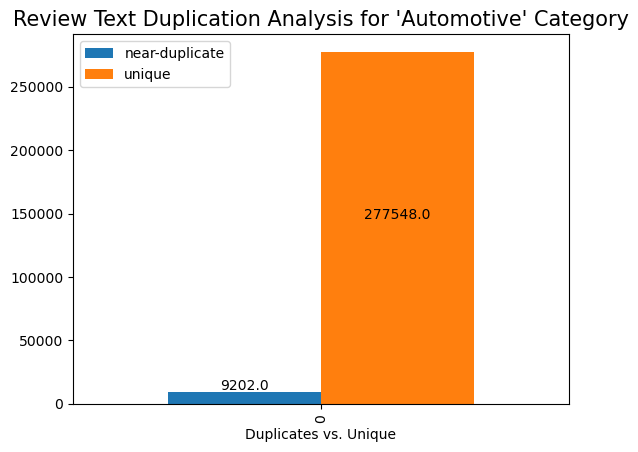

In [26]:
dups_df = pd.DataFrame.from_dict({'near-duplicate': [dups], 'unique': [uniques]})

ax=dups_df.plot(kind = 'bar',y=['near-duplicate', 'unique'], fontsize=10, color=['C0', 'C1'], align='center', width=0.8, xlabel="Duplicates vs. Unique")
ax.set_title("Review Text Duplication Analysis for 'Automotive' Category", fontsize=15)
for p in ax.patches:
       ax.annotate(format(p.get_height(), '.1f'), 
                   (p.get_x() + p.get_width() / 2., p.get_height()/2), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 9), 
                   textcoords = 'offset points') 

In [17]:
df_hashed_text = df_hashed_text.cache()

### Top 5 Products

In [15]:
# get top 5 products
top5 = (auto_sample.groupBy("parent_asin")
        .count()
        .orderBy(F.col("count").desc())
        .limit(5)
        .select("parent_asin")
        .toLocalIterator())
top5_asins = [r["parent_asin"] for r in top5]

In [16]:
df_top5 = df_hashed_text.filter(col("parent_asin").isin(top5_asins))

In [20]:
pairs_top5 = (
    model_text
    .approxSimilarityJoin(df_top5, df_top5, jaccard_distance, distCol="distCol")
    .filter(col("datasetA.id") < col("datasetB.id"))
    # keep ONLY within the same product so each pair belongs to one product
    .filter(col("datasetA.parent_asin") == col("datasetB.parent_asin"))
    .select(
        col("distCol").alias("jaccard_distance"),
        col("datasetA.parent_asin").alias("parent_asin"),
        col("datasetA.id").alias("id_A"),
        col("datasetB.id").alias("id_B"),
    )
    .persist()
)

In [21]:
dup_ids_per_product = (
    pairs_top5.select("parent_asin", col("id_A").alias("id"))
    .union(pairs_top5.select("parent_asin", col("id_B").alias("id")))
    .groupBy("parent_asin")
    .agg(F.countDistinct("id").alias("near_dups"))
)

In [23]:
total_per_product = (
    df_top5.groupBy("parent_asin")
    .agg(F.count("*").alias("records"))
)
summary_top5 = (
    total_per_product.join(dup_ids_per_product, on="parent_asin", how="left")
    .fillna({"near_dups": 0})
    .withColumn("unique", col("records") - col("near_dups"))
    .orderBy(F.desc("records"))
)

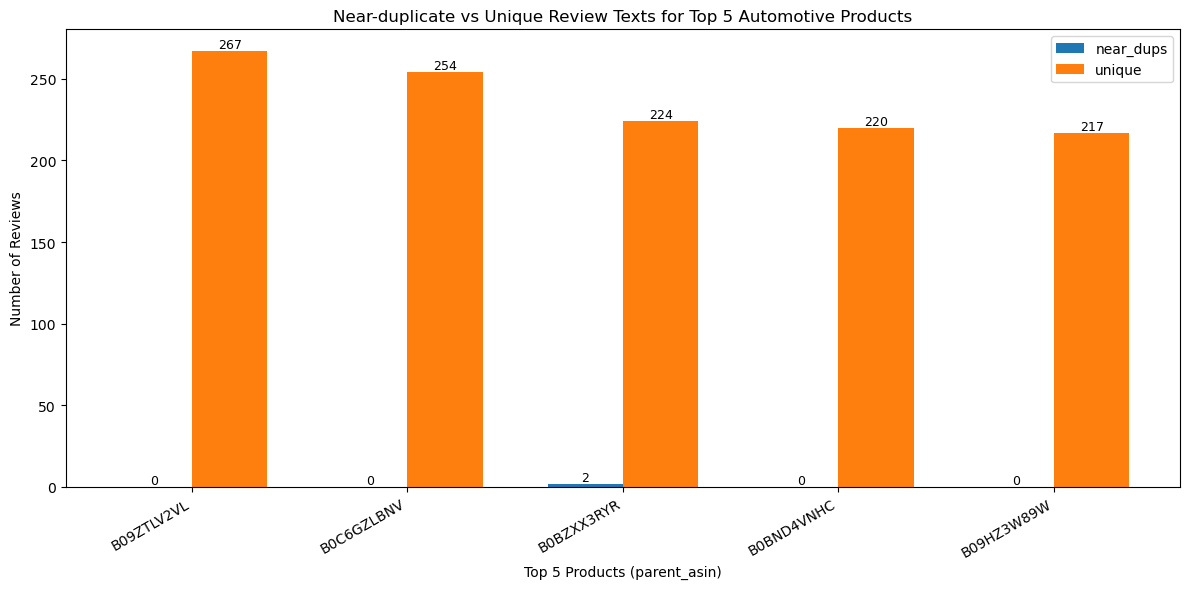

In [24]:
pdf = summary_top5.toPandas()

x = np.arange(len(pdf["parent_asin"]))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width/2, pdf["near_dups"], width, label="near_dups", color="C0")
ax.bar(x + width/2, pdf["unique"],   width, label="unique",   color="C1")

ax.set_xticks(x)
ax.set_xticklabels(pdf["parent_asin"], rotation=30, ha="right")
ax.set_xlabel("Top 5 Products (parent_asin)")
ax.set_ylabel("Number of Reviews")
ax.set_title("Near-duplicate vs Unique Review Texts for Top 5 Automotive Products")
ax.legend()

# optional: value labels
for i, v in enumerate(pdf["near_dups"]):
    ax.text(i - width/2, v, str(int(v)), ha="center", va="bottom", fontsize=9)
for i, v in enumerate(pdf["unique"]):
    ax.text(i + width/2, v, str(int(v)), ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

### Older vs. recent reviews

In [18]:
df_recent = df_hashed_text.filter(year(col("timestamp_df")) >= 2022)
df_older  = df_hashed_text.filter(year(col("timestamp_df")) < 2022)

df_recent = df_recent.filter(F.length("text") >= 5)
df_older  = df_older.filter(F.length("text") >= 5)

In [19]:
df_recent = df_recent.cache()
df_older  = df_older.cache()

In [20]:
def near_dup_stats(df, label):
    pairs = (
        model_text
        .approxSimilarityJoin(df, df, 0.2, distCol="distCol")
        .filter(col("datasetA.id") < col("datasetB.id"))
    )

    dup_ids = (
        pairs.select(col("datasetA.id").alias("id"))
        .union(pairs.select(col("datasetB.id").alias("id")))
        .agg(F.approx_count_distinct("id").alias("dup_ids"))
        .first()["dup_ids"]
    )

    total = df.count()

    return {
        "period": label,
        "total_reviews": total,
        "near_dup_reviews": dup_ids,
        "near_dup_rate": dup_ids / total if total > 0 else 0
    }

recent_stats = near_dup_stats(df_recent, "2022–2023")
older_stats  = near_dup_stats(df_older, "Pre-2022")
print(recent_stats)
print(older_stats)

{'period': '2022–2023', 'total_reviews': 27726, 'near_dup_reviews': 333, 'near_dup_rate': 0.012010387362042848}
{'period': 'Pre-2022', 'total_reviews': 115668, 'near_dup_reviews': 3963, 'near_dup_rate': 0.03426185288930387}


In [21]:
compare_df = pd.DataFrame([
    {
        "period": older_stats["period"],
        "near_dup_rate": older_stats["near_dup_rate"]
    },
    {
        "period": recent_stats["period"],
        "near_dup_rate": recent_stats["near_dup_rate"]
    }
])

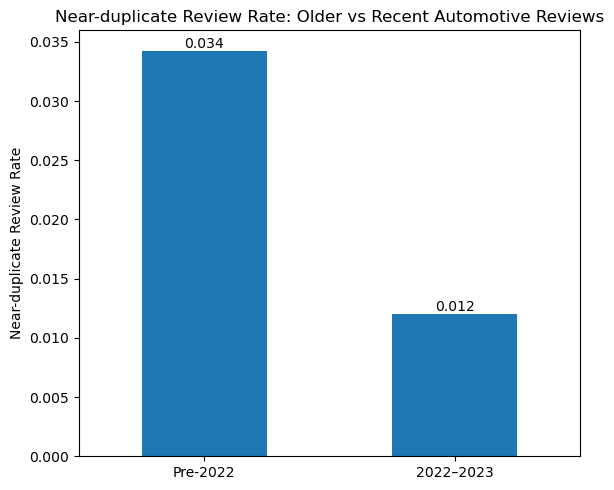

In [23]:
ax = compare_df.plot(
    x="period",
    y="near_dup_rate",
    kind="bar",
    legend=False,
    figsize=(6, 5)
)

ax.set_ylabel("Near-duplicate Review Rate")
ax.set_xlabel("")
ax.set_title("Near-duplicate Review Rate: Older vs Recent Automotive Reviews")
ax.set_xticklabels(compare_df["period"], rotation=0, ha="center")

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.3f}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()